# 01 · Data check (Stage A)

Visual verification of the two things the dataloader must get right (spec §15 step 5):
1. **VOI slice selection** — the max-tumor-area axial slice ±1 (3 slices), same 3 for all sequences.
2. **Whole-tumor volume** — `(seg > 0).sum()`, kept OUT of the model input.

Run: `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/01_data_check.ipynb`

In [1]:
import os, sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "data" / "metadata").exists():
    _root = _root.parent
os.chdir(_root); sys.path.insert(0, str(_root))

%matplotlib inline
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd

from openidh_model.utils.paths import load_paths
from openidh_model.data.dataset import GliomaDataset, MODALITIES
from openidh_model.data.metadata import resolve_subject_dir
from openidh_model.data.transforms import select_slices

paths = load_paths("configs/paths.local.yaml")
print("data:", paths.data_dir)

data: /workspace/data/preprocessed/v1.0.0


## Build the dataset (random 5-fold file, all rows) and report coverage

In [2]:
ds = GliomaDataset(paths.splits_dir / "splits_random_5fold.csv", paths, role=None)
print(f"usable subjects: {len(ds)}   missing image dirs: {len(ds.missing)}")
# one subject per site
picks = {}
for i, r in enumerate(ds.rows):
    picks.setdefault(r["site"], i)
    if len(picks) == 3:
        break
print("examples:", {s: ds.rows[i]["subject_id"] for s, i in picks.items()})

usable subjects: 8175   missing image dirs: 0
examples: {'UCSF': 'UCSF-PDGM-004', 'UTSW': 'BT0002', 'UPenn': 'UPENN-GBM-00001_11'}


## VOI slice selection — tumor area vs z
The chosen slice is the argmax of tumor area; we take it and its two neighbors.

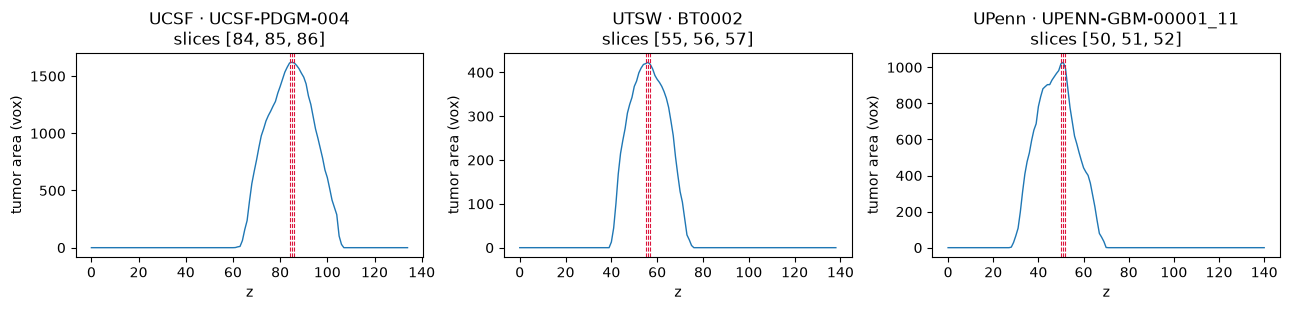

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (site, i) in zip(axes, picks.items()):
    r = ds.rows[i]
    seg = np.asarray(nib.load(resolve_subject_dir(paths.data_dir, site, r["subject_id"]) / "volumes" / "tumor_seg.nii.gz").dataobj)
    area = (seg > 0).sum(axis=(0, 1))
    z = select_slices(seg)
    ax.plot(area, lw=1)
    for zz in z:
        ax.axvline(zz, color="crimson", ls="--", lw=0.8)
    ax.set_title(f"{site} · {r['subject_id']}\nslices {z}")
    ax.set_xlabel("z"); ax.set_ylabel("tumor area (vox)")
plt.tight_layout(); plt.show()

## Chosen slice + tumor overlay, per modality
Middle VOI slice of each sequence with the tumor segmentation contour. The SAME
3 slices are used across all sequences (co-registered), so anatomy lines up.

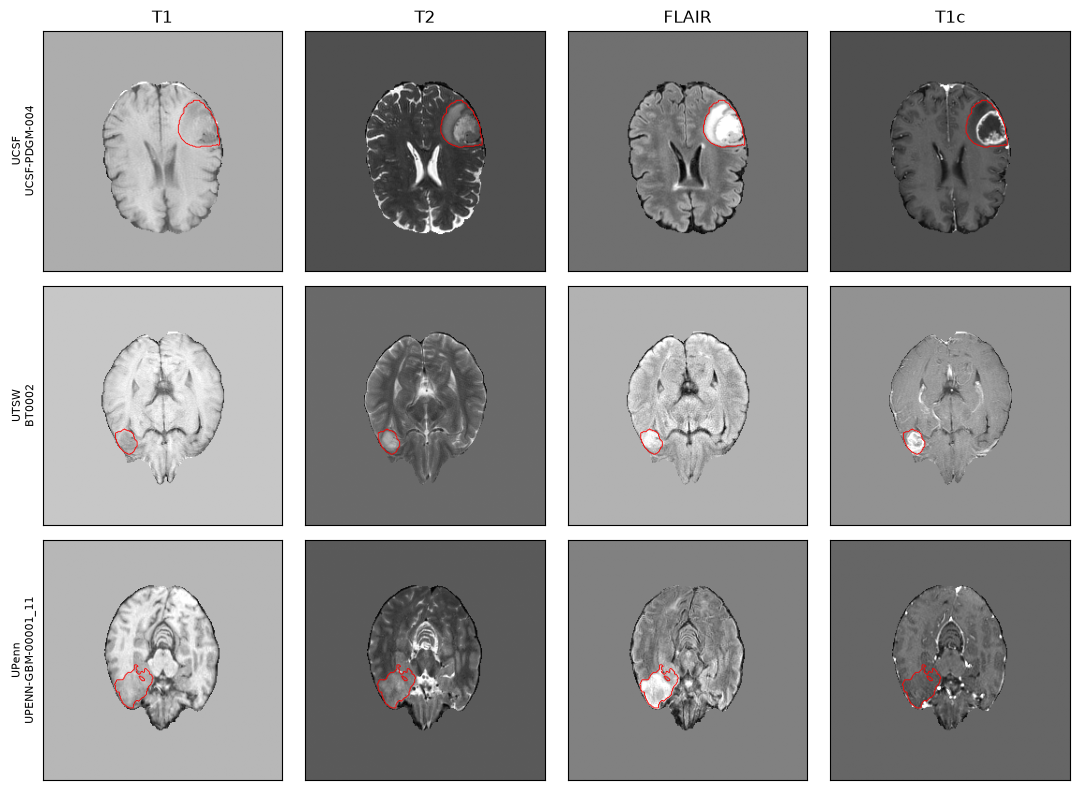

In [4]:
fig, axes = plt.subplots(len(picks), len(MODALITIES), figsize=(11, 8))
for row, (site, i) in enumerate(picks.items()):
    r = ds.rows[i]
    vdir = resolve_subject_dir(paths.data_dir, site, r["subject_id"]) / "volumes"
    seg = np.asarray(nib.load(vdir / "tumor_seg.nii.gz").dataobj)
    zc = select_slices(seg)[1]  # middle chosen slice
    for col, m in enumerate(MODALITIES):
        ax = axes[row, col]
        arr = np.asarray(nib.load(vdir / f"{m}.nii.gz").dataobj)
        ax.imshow(np.rot90(arr[:, :, zc]), cmap="gray")
        ax.contour(np.rot90((seg[:, :, zc] > 0)), colors="red", linewidths=0.6)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(m)
        if col == 0:
            ax.set_ylabel(f"{site}\n{r['subject_id']}", fontsize=8)
plt.tight_layout(); plt.show()

## Volume cross-check vs the UTSW seg inventory
The dataset's whole-tumor voxel count must equal `tumor_seg_voxel_count` in the inventory.

In [5]:
inv = pd.read_csv(paths.data_dir / "utsw-glioma" / "_global" / "seg_source_inventory.csv")
inv = inv.set_index("subject_id")["tumor_seg_voxel_count"].to_dict()
checked = 0
for i, r in enumerate(ds.rows):
    if r["site"] != "UTSW" or r["subject_id"] not in inv:
        continue
    v_ds = int(ds[i]["volume"].item())
    v_inv = int(inv[r["subject_id"]])
    assert v_ds == v_inv, f"{r['subject_id']}: {v_ds} != {v_inv}"
    checked += 1
    if checked >= 8:
        break
print(f"volume matches inventory for {checked} UTSW subjects (exact)")

volume matches inventory for 8 UTSW subjects (exact)


## ✅ Stage A data check passed
VOI selection and whole-tumor volume verified on real data across all three sites,
and volumes match the inventory exactly. Next: losses (KL tests) and fusion (already
implemented + tested in `tests/test_invariants.py`).